In [1]:
import os
import math
import random
import urllib.request

import torch
import torch.nn as nn


# =========================
# 1. Reproducibility
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


# =========================
# 2. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# 3. Download / Load Tiny Shakespeare
# =========================
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

txt_path = os.path.join(DATA_DIR, "tiny_shakespeare.txt")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

if not os.path.exists(txt_path):
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(url, txt_path)
    print("Download finished.")

with open(txt_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Total characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Using device: cuda
Download finished.
Total characters: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [2]:
!pip install tokenizers

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer

In [3]:

tokenizer = Tokenizer(BPE(unk_token="<UNK>"))


tokenizer.pre_tokenizer = Whitespace()


trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["<PAD>", "<UNK>"]
)
tokenizer.train([txt_path], trainer)
vocab = tokenizer.get_vocab()
print("Vocab size:", len(vocab))

Vocab size: 500


In [4]:
encoded = tokenizer.encode(text)
all_token_ids = encoded.ids


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

def build_sequences(token_ids, seq_len=50, stride=25):
    inputs = []
    targets = []

    # create x and y using a sliding window
    for start in range(0, len(token_ids) - (seq_len + 1), stride):
        window = token_ids[start : start + seq_len + 1]

        x = window[:-1]   
        y = window[1:]    

        inputs.append(x)
        targets.append(y)

    return inputs, targets

seq_len = 50
stride = 25  

inputs, targets = build_sequences(all_token_ids, seq_len=seq_len, stride=stride)


print("\nFirst input sample:")
print(inputs[0])

print("\nFirst target sample:")
print(targets[0])


First input sample:
[405, 15, 91, 47, 64, 73, 10, 394, 281, 114, 298, 99, 108, 422, 44, 136, 129, 6, 393, 79, 363, 8, 13, 78, 10, 31, 152, 250, 6, 363, 8, 405, 15, 91, 47, 64, 73, 10, 316, 156, 133, 56, 84, 314, 90, 42, 143, 129, 80, 275]

First target sample:
[15, 91, 47, 64, 73, 10, 394, 281, 114, 298, 99, 108, 422, 44, 136, 129, 6, 393, 79, 363, 8, 13, 78, 10, 31, 152, 250, 6, 363, 8, 405, 15, 91, 47, 64, 73, 10, 316, 156, 133, 56, 84, 314, 90, 42, 143, 129, 80, 275, 43]


In [6]:
#split without shuffling
split_idx = int(0.8 * len(inputs))

train_inputs = inputs[:split_idx]
train_targets = targets[:split_idx]

val_inputs = inputs[split_idx:]
val_targets = targets[split_idx:]

print("Train samples:", len(train_inputs))
print("Val samples:", len(val_inputs))

Train samples: 14325
Val samples: 3582


In [7]:
class ShakespeareDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.long)
        y = torch.tensor(self.targets[idx], dtype=torch.long)
        return x, y

In [8]:
train_dataset = ShakespeareDataset(train_inputs, train_targets)
val_dataset = ShakespeareDataset(val_inputs, val_targets)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [9]:
#sanity check
print("Check shifted relation:")
print("x[:10] =", train_inputs[0][:10])
print("y[:10] =", train_targets[0][:10])

Check shifted relation:
x[:10] = [405, 15, 91, 47, 64, 73, 10, 394, 281, 114]
y[:10] = [15, 91, 47, 64, 73, 10, 394, 281, 114, 298]


In [10]:
#embedding
import math
import torch
import torch.nn as nn

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)   # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)  # (max_len, 1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)   # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: (batch_size, seq_len, d_model)
        """
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]
    
class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=512):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_encoding = SinusoidalPositionalEncoding(d_model, max_len=max_len)

    def forward(self, x):
        """
        x: (batch_size, seq_len)
        """
        x = self.token_embedding(x)   # (batch_size, seq_len, d_model)
        x = self.position_encoding(x) # (batch_size, seq_len, d_model)
        return x
    

vocab_size = len(vocab)
d_model = 128
max_len = seq_len   #50

embedding_layer = InputEmbedding(vocab_size, d_model, max_len=max_len).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

x_emb = embedding_layer(x_batch)

print("x_batch shape:", x_batch.shape)
print("x_emb shape:", x_emb.shape)

x_batch shape: torch.Size([32, 50])
x_emb shape: torch.Size([32, 50, 128])


In [11]:
print(x_batch[0, :10])
print(x_emb[0, :2, :8])

tensor([110,  63, 131,  45,  56,  81, 389,  88,   5,  57], device='cuda:0')
tensor([[ 0.0768,  1.7169,  0.3532,  1.4590,  0.0466,  2.3238,  0.3379, -0.4681],
        [ 1.5620,  0.2570,  0.8555,  2.3053,  1.8115,  1.3650,  0.8401,  0.8811]],
       device='cuda:0', grad_fn=<SliceBackward0>)


In [12]:
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        #automatically randomly initialized linear layers for Q, K, V
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        """
        x: (batch_size, seq_len, d_model)
        returns:
            out: (batch_size, seq_len, d_model)
            attn_weights: (batch_size, seq_len, seq_len)
        """
        batch_size, seq_len, d_model = x.shape

        # 1. project to Q, K, V
        Q = self.W_q(x)   # (B, T, D)
        K = self.W_k(x)   # (B, T, D)
        V = self.W_v(x)   # (B, T, D)

        # 2. attention scores
        # K.transpose(-2, -1): (B, D, T)
        scores = Q @ K.transpose(-2, -1)   # (B, T, T)

        # 3. scale
        scores = scores / math.sqrt(d_model)

        # 4. causal mask
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1)
        scores = scores.masked_fill(mask == 1, float('-inf'))

        # 5. softmax -> attention weights
        #T = 50, since we have 50 tokens in each input sequence, each row of scores corresponds to one token looking to all tokens (including itself, so total of n columns), 
        # so we softmax over the last dimension (the seq_len dimension) to get the attention distribution for each token.
        # B=32, we have 32 sentences in each training subset.
        attn_weights = torch.softmax(scores, dim=-1)   # (B, T, T)

        # 6. weighted sum of V
        out = attn_weights @ V   # (B, T, D)

        return out, attn_weights

In [13]:
attention_layer = SingleHeadSelfAttention(d_model=128).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

x_emb = embedding_layer(x_batch)   # (B, T, D)
attn_out, attn_weights = attention_layer(x_emb)

print("x_emb shape:", x_emb.shape)
print("attn_out shape:", attn_out.shape)
#total attention weights
print("attn_weights shape:", attn_weights.shape)

x_emb shape: torch.Size([32, 50, 128])
attn_out shape: torch.Size([32, 50, 128])
attn_weights shape: torch.Size([32, 50, 50])


In [14]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        """
        x: (B, T, D)
        """
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        x_norm = x / rms
        return self.scale * x_norm

# FFN
class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(d_model, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, d_model)

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.fc2(self.act(self.fc1(x)))

In [15]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, ff_hidden_dim):
        super().__init__()
        self.attention = SingleHeadSelfAttention(d_model)
        self.norm1 = RMSNorm(d_model)

        self.ffn = FeedForward(d_model, ff_hidden_dim)
        self.norm2 = RMSNorm(d_model)

    def forward(self, x):
        """
        x: (B, T, D)

        returns:
            x: (B, T, D)
            attn_weights: (B, T, T)
        """
        # 1) attention + residual + norm
        attn_out, attn_weights = self.attention(x)
        x = self.norm1(x + attn_out)

        # 2) FFN + residual + norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        return x, attn_weights

In [16]:
block = TransformerBlock(d_model=128, ff_hidden_dim=256).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

x_emb = embedding_layer(x_batch)
x_block, attn_weights = block(x_emb)

print("x_emb shape:", x_emb.shape)
print("x_block shape:", x_block.shape)
print("attn_weights shape:", attn_weights.shape)

x_emb shape: torch.Size([32, 50, 128])
x_block shape: torch.Size([32, 50, 128])
attn_weights shape: torch.Size([32, 50, 50])


In [17]:
class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model, max_len, num_blocks=2, ff_hidden_dim=256):
        super().__init__()
        self.embedding = InputEmbedding(vocab_size, d_model, max_len=max_len)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, ff_hidden_dim) for _ in range(num_blocks)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        """
        x: (B, T)
        returns:
            logits: (B, T, vocab_size)
            all_attn_weights: list of (B, T, T)
        """
        x = self.embedding(x)   # (B, T, D)

        all_attn_weights = []
        for block in self.blocks:
            x, attn_weights = block(x)
            all_attn_weights.append(attn_weights)

        logits = self.lm_head(x)   # (B, T, vocab_size)
        return logits, all_attn_weights

In [18]:
vocab_size = len(vocab)   # 或 tokenizer.get_vocab_size()

model = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=128,
    max_len=seq_len,
    num_blocks=2,
    ff_hidden_dim=256
).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)

logits, all_attn_weights = model(x_batch)

print("x_batch shape:", x_batch.shape)
print("logits shape:", logits.shape)
print("num attention maps:", len(all_attn_weights))
print("one attention map shape:", all_attn_weights[0].shape)

x_batch shape: torch.Size([32, 50])
logits shape: torch.Size([32, 50, 500])
num attention maps: 2
one attention map shape: torch.Size([32, 50, 50])


In [19]:
import math
import torch

def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits, _ = model(x_batch)   # (B, T, V)
            B, T, V = logits.shape

            loss = criterion(
                logits.view(B * T, V),
                y_batch.view(B * T)
            )

            total_loss += loss.item() * (B * T)
            total_tokens += (B * T)

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)

    return avg_loss, ppl

In [20]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

train_losses = []
val_losses = []
val_ppls = []

for epoch in range(num_epochs):
    model.train()

    total_train_loss = 0.0
    total_train_tokens = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits, _ = model(x_batch)   # (B, T, V)
        B, T, V = logits.shape

        loss = criterion(
            logits.view(B * T, V),
            y_batch.view(B * T)
        )

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * (B * T)
        total_train_tokens += (B * T)

    avg_train_loss = total_train_loss / total_train_tokens
    avg_val_loss, val_ppl = evaluate(model, val_loader, criterion, device)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_ppls.append(val_ppl)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val PPL:    {val_ppl:.4f}")

Epoch 1/10
  Train Loss: 4.5330
  Val Loss:   4.3776
  Val PPL:    79.6440
Epoch 2/10
  Train Loss: 3.8382
  Val Loss:   4.2178
  Val PPL:    67.8849
Epoch 3/10
  Train Loss: 3.6316
  Val Loss:   4.1777
  Val PPL:    65.2181
Epoch 4/10
  Train Loss: 3.5059
  Val Loss:   4.1375
  Val PPL:    62.6467
Epoch 5/10
  Train Loss: 3.4169
  Val Loss:   4.1282
  Val PPL:    62.0631
Epoch 6/10
  Train Loss: 3.3490
  Val Loss:   4.1151
  Val PPL:    61.2607
Epoch 7/10
  Train Loss: 3.2932
  Val Loss:   4.1070
  Val PPL:    60.7612
Epoch 8/10
  Train Loss: 3.2478
  Val Loss:   4.1181
  Val PPL:    61.4399
Epoch 9/10
  Train Loss: 3.2082
  Val Loss:   4.1202
  Val PPL:    61.5725
Epoch 10/10
  Train Loss: 3.1735
  Val Loss:   4.1319
  Val PPL:    62.2964


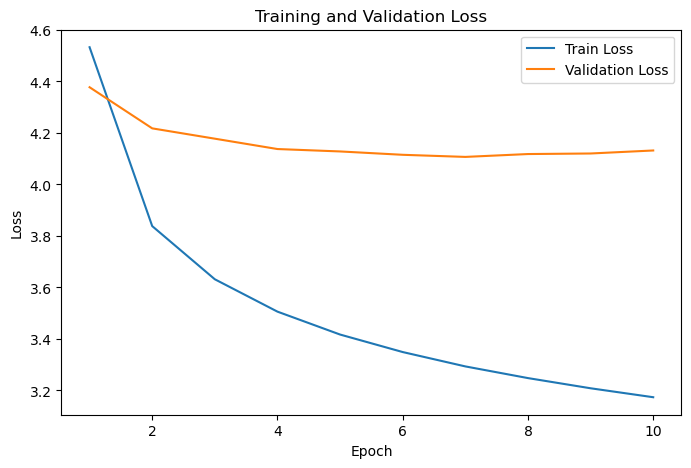

In [21]:
import matplotlib.pyplot as plt

epochs = list(range(1, num_epochs + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

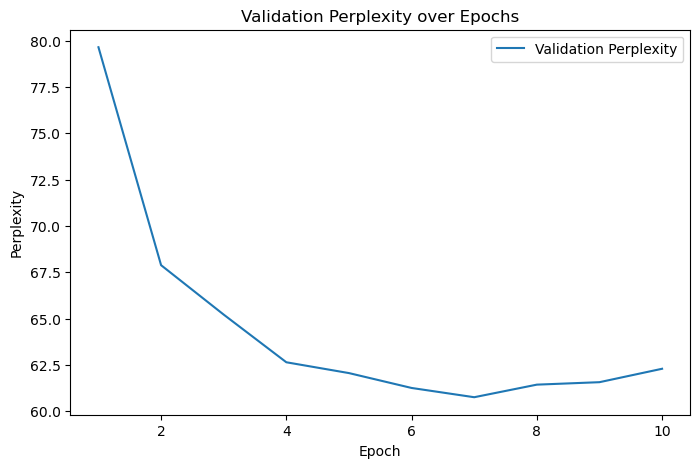

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_ppls, label="Validation Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity over Epochs")
plt.legend()
plt.show()

In [23]:
model.eval()

with torch.no_grad():
    x_sample, y_sample = next(iter(val_loader))
    x_sample = x_sample.to(device)

    logits, all_attn_weights = model(x_sample)

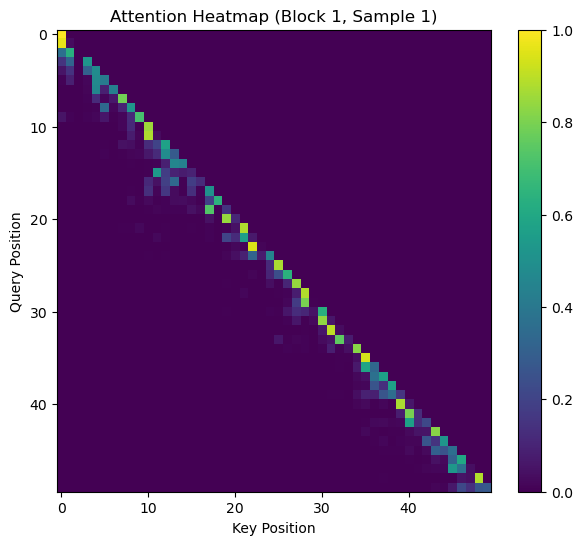

In [24]:
attn_matrix = all_attn_weights[0][0].cpu()   # shape: (T, T)

plt.figure(figsize=(7, 6))
plt.imshow(attn_matrix, aspect="auto")
plt.colorbar()
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.title("Attention Heatmap (Block 1, Sample 1)")
plt.show()

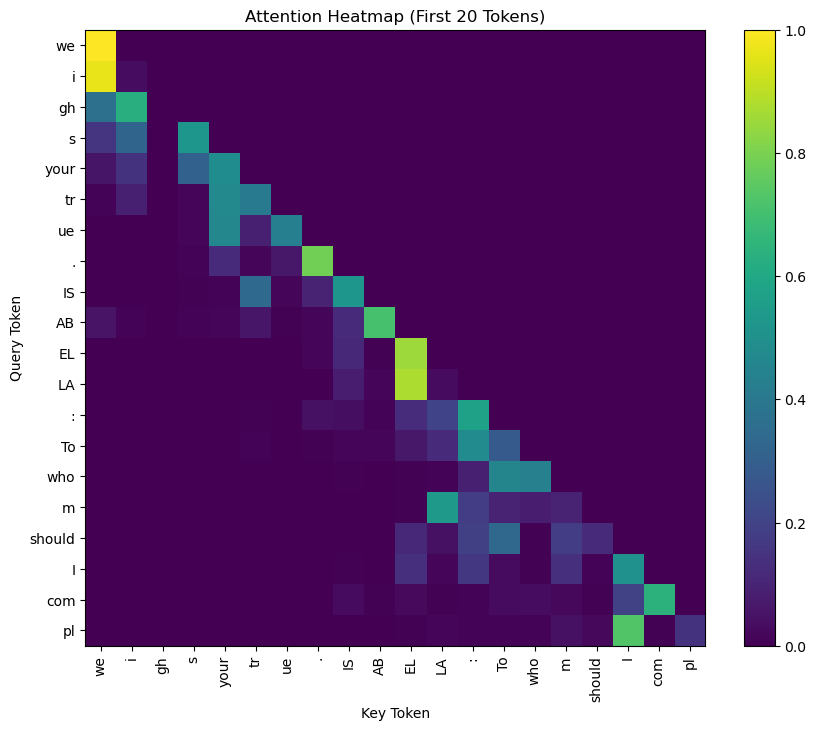

In [26]:
small_attn = attn_matrix[:20, :20]
small_tokens = tokens[:small_attn.shape[0]]

plt.figure(figsize=(10, 8))
plt.imshow(small_attn, aspect="auto")
plt.colorbar()
plt.xticks(range(small_attn.shape[1]), small_tokens, rotation=90)
plt.yticks(range(small_attn.shape[0]), small_tokens)
plt.xlabel("Key Token")
plt.ylabel("Query Token")
plt.title("Attention Heatmap (First 20 Tokens)")
plt.show()